# Tarefa de Machine Learning: Regressão e Classificação

**Nome:** Leticia Pessôa Machado

Notebook com duas partes:
1. Regressão (Student Performance)
2. Classificação (Breast Cancer Wisconsin)


In [13]:
# Importações
# Bibliotecas de manipulação e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do scikit-learn para validação cruzada, pipeline e pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Algoritmos de Machine Learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Métricas de avaliação de perfomance dos modelos
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Semente aleatória -> garantir reprodutibilidade
RANDOM_STATE = 42
# Estilo padrão dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


---
# Parte 1: Regressão — Student Performance


## 1.1 Análise exploratória (EDA)

In [14]:
df_reg = pd.read_csv("regressao/train.csv")
test_reg = pd.read_csv("regressao/test.csv")

print(df_reg.shape, test_reg.shape)
df_reg.head()


(395, 31) (20, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [15]:
df_reg.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

In [16]:
# Estatísticas descritivas e checagem de nulos
display(df_reg.describe(include="all").T)
print("\nValores nulos por coluna:")
print(df_reg.isnull().sum()[df_reg.isnull().sum() > 0])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Valores nulos por coluna:
Series([], dtype: int64)


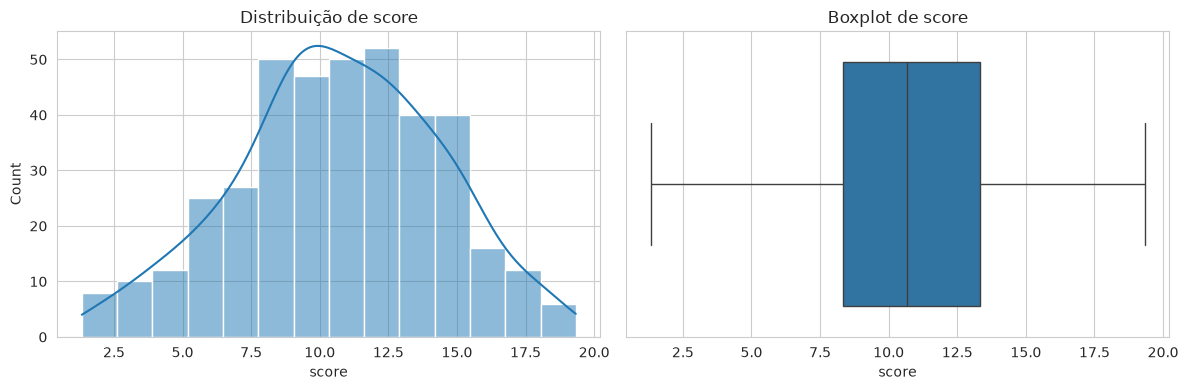

count    395.000000
mean      10.679139
std        3.696912
min        1.330000
25%        8.330000
50%       10.670000
75%       13.330000
max       19.330000
Name: score, dtype: float64


In [17]:
# Distribuição do alvo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_reg["score"], kde=True, ax=ax[0])
ax[0].set_title("Distribuição de score")
sns.boxplot(x=df_reg["score"], ax=ax[1])
ax[1].set_title("Boxplot de score")
plt.tight_layout()
plt.show()

print(df_reg["score"].describe())


In [18]:
# Colunas numéricas vs categóricas (texto)
num_cols = df_reg.select_dtypes(include=[np.number]).columns.drop("score").tolist()
cat_cols = df_reg.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas/ordinais:", num_cols)
print("Categóricas (texto):", cat_cols)

Numéricas/ordinais: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categóricas (texto): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/tmp/ipykernel_7854/1463021580.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_reg.select_dtypes(include=["object"]).columns.tolist()


score         1.000000
Medu          0.224220
Fedu          0.175822
studytime     0.134546
famrel        0.021631
freetime      0.003773
absences     -0.005978
Dalc         -0.072502
health       -0.080333
Walc         -0.088042
traveltime   -0.128141
age          -0.134566
goout        -0.154530
failures     -0.375702
Name: score, dtype: float64


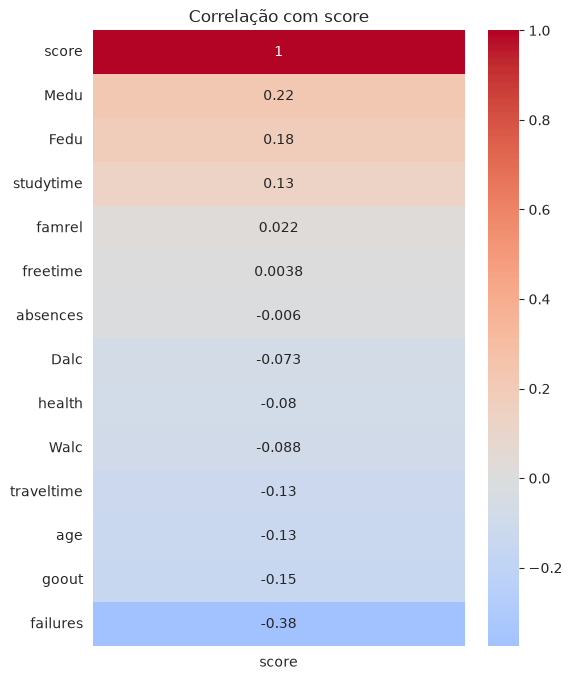

In [19]:
# Correlação das variáveis numéricas com o alvo
corr = df_reg[num_cols + ["score"]].corr()["score"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(6, 8))
sns.heatmap(df_reg[num_cols + ["score"]].corr()[["score"]].sort_values("score", ascending=False),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlação com score")
plt.show()


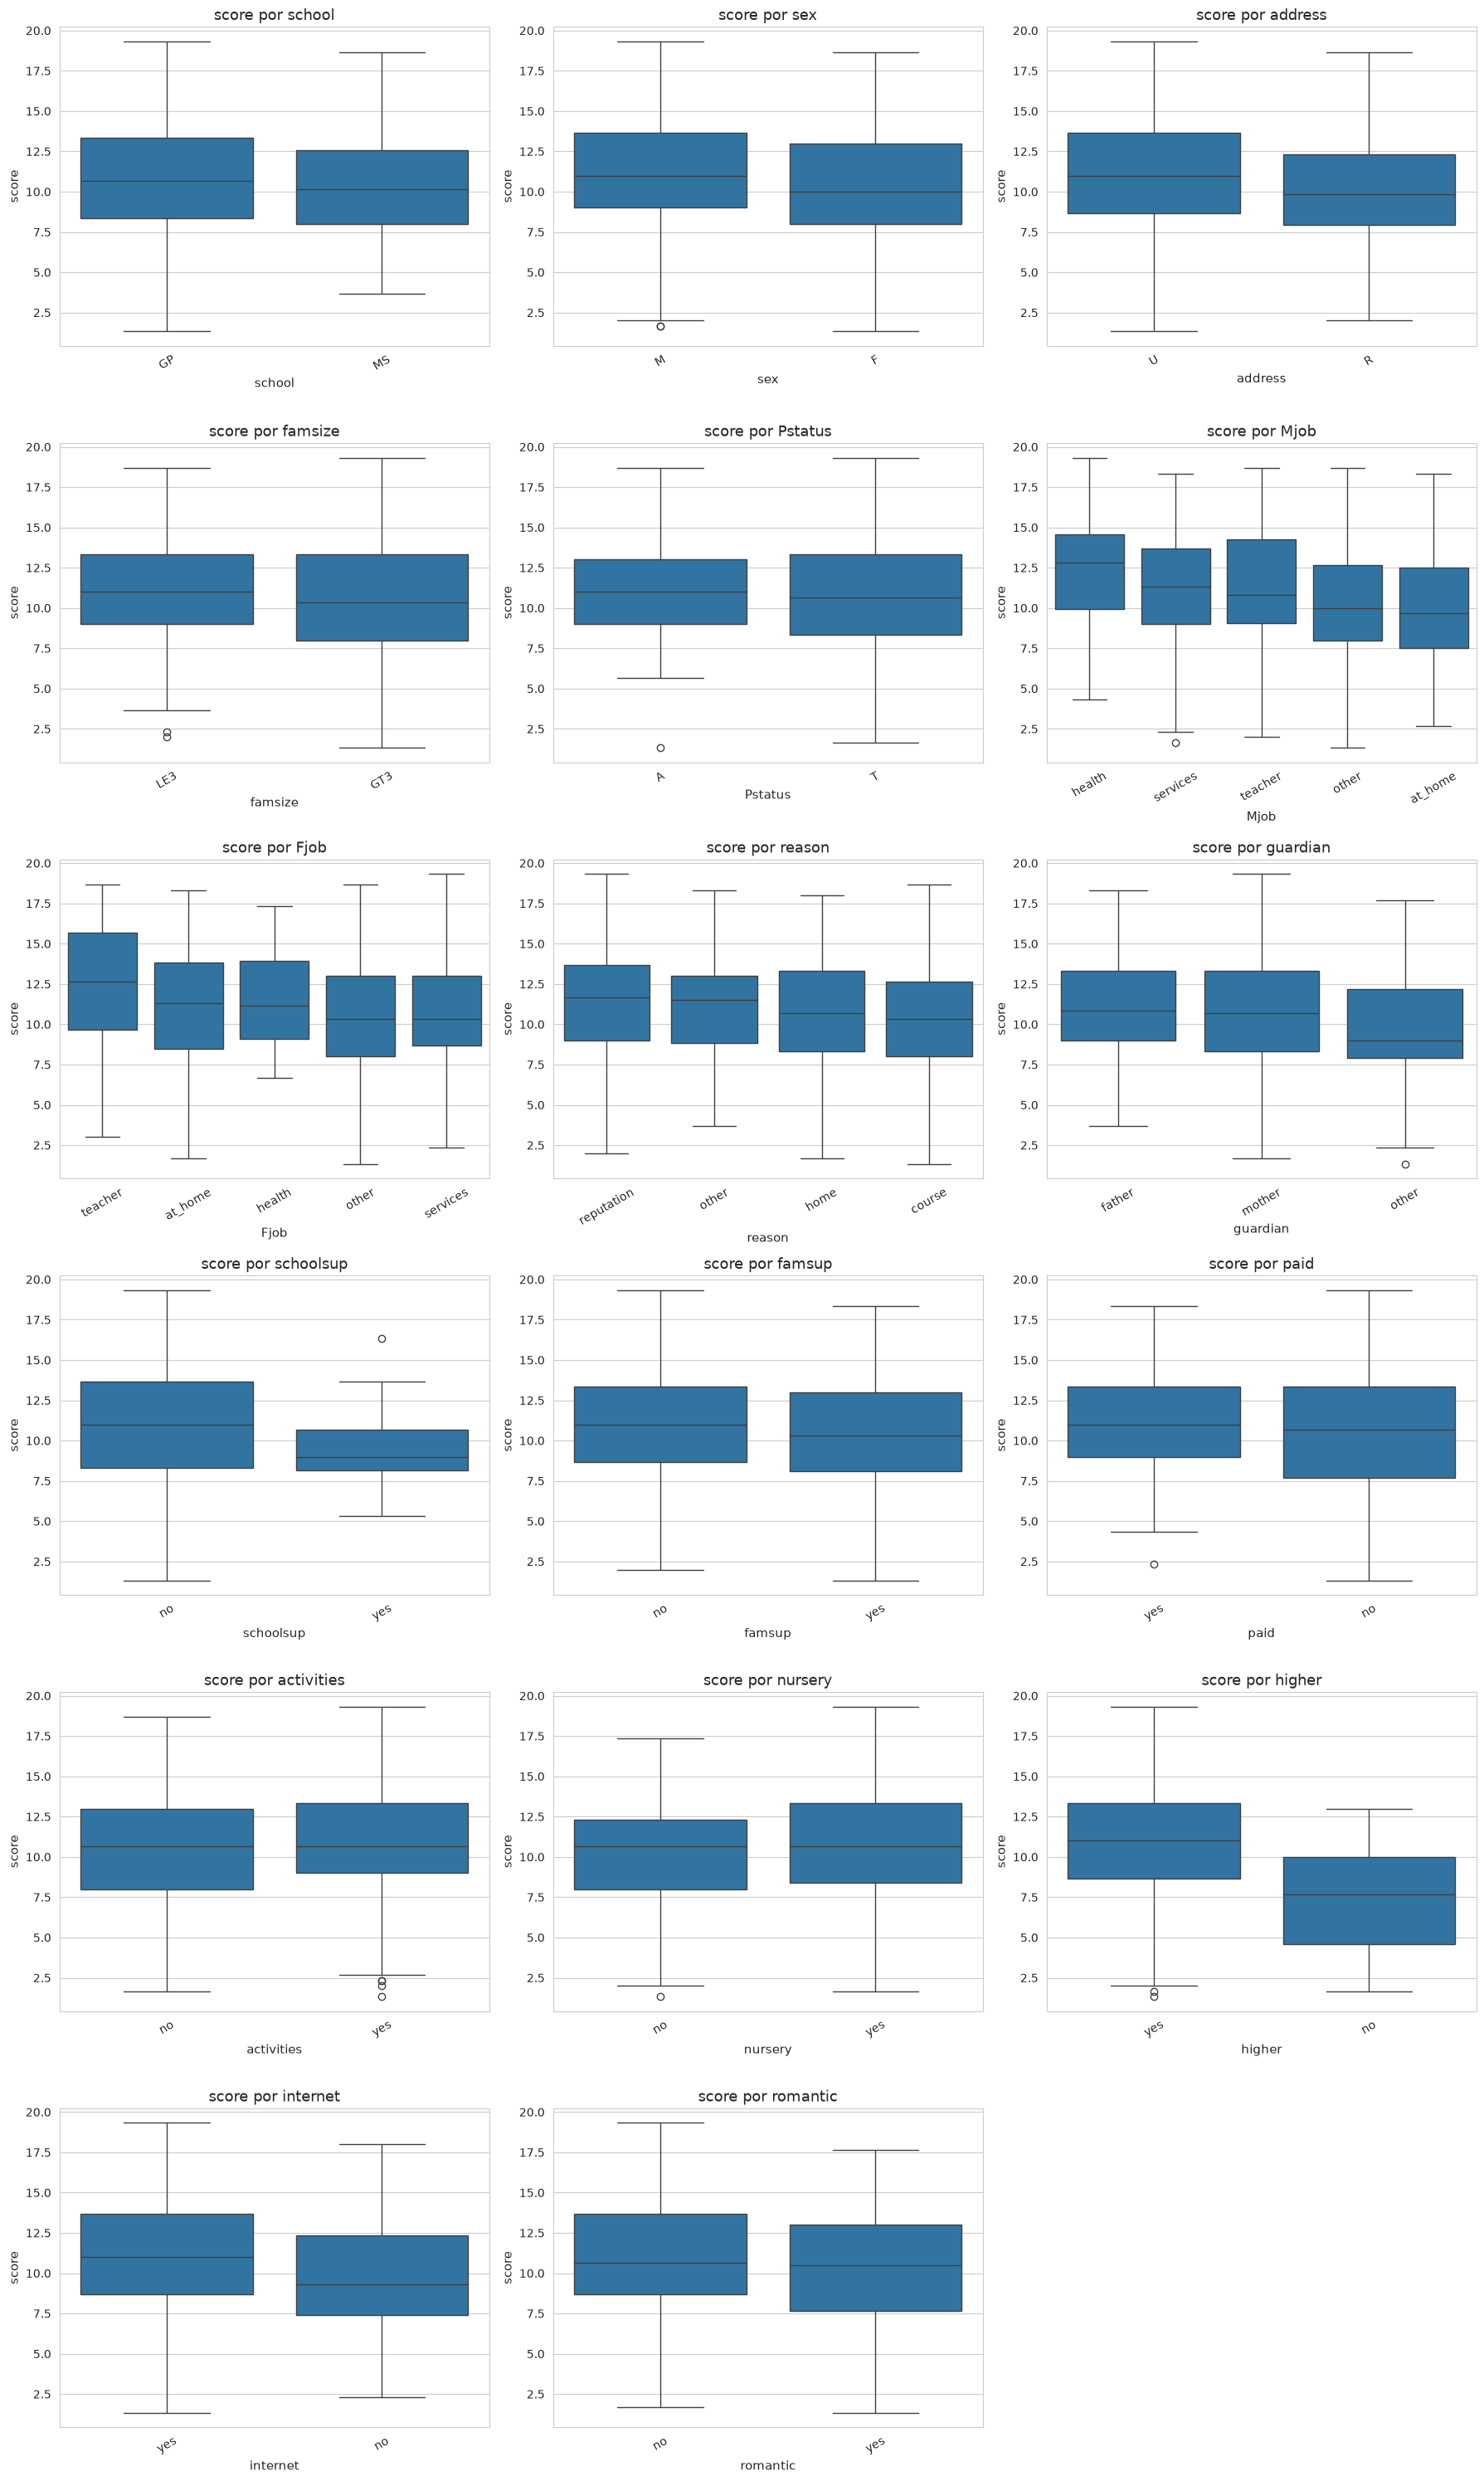

In [43]:
# Score médio por variável categórica (ex: Mjob, reason, guardian)
n = len(cat_cols)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.ravel()

for ax, c in zip(axes, cat_cols):
    order = df_reg.groupby(c)["score"].median().sort_values(ascending=False).index
    sns.boxplot(data=df_reg, x=c, y="score", ax=ax, order=order)
    ax.set_title(f"score por {c}", fontsize=13)
    ax.set_xlabel(c, fontsize=11)
    ax.set_ylabel("score", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

# remove eixos vazios sobrando
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Conclusões da EDA:** A análise exploratória inicial revela que o conjunto de dados de treino é composto por 395 registros e 31 variáveis (sendo 14 numéricas e 17 categóricas), e apresenta excelente completude, sem nenhum valor nulo. O conjunto de teste conta com 20 registros e 30 colunas. O perfil demográfico da base indica um predomínio de estudantes do sexo feminino (208) e matriculados na escola 'GP' (349), com uma média de idade de 16,7 anos, variando entre 15 e 22 anos. Por fim, a variável alvo contínua, referente à pontuação (score) dos alunos, varia de 1,33 a 19,33, estabelecendo uma média geral de aproximadamente 10,68.

## 1.2 Limpeza e pré-processamento

In [44]:
# Confirma que test.csv tem as mesmas colunas de features (sem 'score')
assert set(test_reg.columns) == set(df_reg.columns) - {"score"}, "colunas de test.csv não batem com train.csv"

X = df_reg.drop(columns=["score"])
y = df_reg["score"]

# Pipeline de pré-processamento:
# - numéricas/ordinais -> imputa mediana + padroniza
# - categóricas (texto) -> imputa moda + one-hot encoding
preprocessor_reg = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])


1. Verificação de integridade dos dados
Antes de qualquer transformação, foi validado que test.csv tem exatamente o mesmo conjunto de colunas de train.csv, exceto a variável-alvo (score). Isso garante que o pipeline treinado poderá ser aplicado ao teste sem erro de schema. Também chequei isnull().sum() — não havia valores ausentes neste dataset, mas o pipeline inclui imputação por precaução (dados futuros ou reamostragens podem introduzir NaN).

2. Separação de tipos de variável
As 30 features foram divididas em dois grupos, com base no dtype do pandas:

Numéricas/ordinais (`select_dtypes(include=[np.number])`): incluem tanto variáveis contínuas (absences) quanto ordinais codificadas como inteiros (Medu, Fedu, studytime, famrel, freetime, goout, Dalc, Walc, health — escalas Likert de 1–5, conforme student.txt). Elas foram tratadas como numéricas porque a ordem entre os níveis é significativa e a maioria dos modelos testados (lineares, baseados em distância) se beneficia dessa relação de ordem sendo preservada.
Categóricas nominais (`select_dtypes(include=["object"])`): variáveis sem ordem natural, como Mjob, Fjob, reason, guardian, além das binárias (school, sex, address, schoolsup etc.).

3. Pipeline de transformação (ColumnTransformer)

Ramo numérico: `SimpleImputer(strategy="median")` seguido de `StandardScaler()`. A padronização é necessária para modelos sensíveis à escala (KNN, SVR, regressões regularizadas com Ridge/Lasso), que de outra forma dariam peso desproporcional a variáveis com magnitude maior (ex: absences de 0–93 vs. famrel de 1–5).
Ramo categórico: `SimpleImputer(strategy="most_frequent")` seguido de `OneHotEncoder(handle_unknown="ignore")`, que expande cada categoria nominal em colunas binárias. O parâmetro `handle_unknown="ignore" evita falha caso o conjunto de teste contenha uma categoria não vista no treino.

Essas duas etapas foram encapsuladas dentro de um Pipeline do scikit-learn e combinadas via ColumnTransformer, o que garante que a mesma transformação (com os mesmos parâmetros, ex. média usada na imputação, aprendidos apenas no treino) seja aplicada de forma consistente ao conjunto de teste — evitando vazamento de dados (data leakage).

## 1.3 Modelos de Inferência

Foram comparados 9 algoritmos de regressão, cobrindo diferentes vieses indutivos:

| Categoria | Modelos | Suposição/mecanismo |
|---|---|---|
| Linear | `LinearRegression` | relação linear entre features e alvo; baseline interpretável |
| Linear regularizada | `Ridge` (L2), `Lasso` (L1), `ElasticNet` (L1+L2) | penalizam coeficientes grandes para reduzir overfitting/variância; Lasso zera coeficientes (seleção de features embutida) |
| Baseada em distância | `KNeighborsRegressor` | prediz pela média dos *k* vizinhos mais próximos no espaço padronizado; não-paramétrico, sem forma funcional assumida |
| Baseada em margem | `SVR` | encontra função que mantém erros dentro de uma margem ε; kernel RBF permite capturar não-linearidades |
| Árvore única | `DecisionTreeRegressor` | particiona o espaço de features recursivamente por divisões que minimizam variância; captura interações mas tende a overfitting |
| Ensemble (bagging) | `RandomForestRegressor` | agrega várias árvores treinadas em amostras bootstrap com subconjuntos aleatórios de features; reduz variância do modelo base |
| Ensemble (boosting) | `GradientBoostingRegressor` | treina árvores sequencialmente, cada uma corrigindo o erro residual da anterior; reduz viés |

Todos os modelos foram encapsulados no mesmo `Pipeline` de pré-processamento, garantindo
comparação justa (mesma transformação de entrada para todos).

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}


## 1.4 Métrica de Avaliação e Validação Cruzada

**Métrica: RMSE (Root Mean Squared Error)**

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Penaliza quadraticamente erros grandes (sensível a outliers) e está na mesma unidade do
alvo (pontos de 0–20), o que facilita interpretação direta.

**Protocolo de validação: K-Fold Cross-Validation (k=5)**
O conjunto de treino é particionado em 5 folds. Em cada iteração, 4 folds treinam o modelo
e o fold restante é usado para avaliação; o processo se repete 5 vezes, alternando o fold
de teste. O resultado reportado é a **média e o desvio-padrão do RMSE** entre os 5 folds
(`cross_val_score` com `scoring="neg_mean_squared_error"`, convertido para RMSE via raiz
quadrada do valor absoluto).

Isso é preferível a um único split treino/teste porque:
1. Usa todo o conjunto de treino tanto para ajuste quanto para validação (em rodadas
   diferentes), reduzindo variância da estimativa de desempenho.
2. O desvio-padrão entre folds indica a estabilidade do modelo frente a diferentes
   amostras dos dados — relevante dado o tamanho pequeno do dataset (395 amostras).



In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results_reg = []

for name, model in reg_models.items():
    pipe = Pipeline([("prep", preprocessor_reg), ("model", model)])
    neg_mse = cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-neg_mse)
    results_reg.append({"modelo": name, "rmse_mean": rmse_scores.mean(), "rmse_std": rmse_scores.std()})
    print(f"{name:20s} RMSE = {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}")

results_reg_df = pd.DataFrame(results_reg).sort_values("rmse_mean")
results_reg_df


LinearRegression     RMSE = 3.459 +/- 0.111
Ridge                RMSE = 3.452 +/- 0.104
Lasso                RMSE = 3.563 +/- 0.265
ElasticNet           RMSE = 3.498 +/- 0.259
KNN                  RMSE = 3.596 +/- 0.265
SVR                  RMSE = 3.342 +/- 0.245
DecisionTree         RMSE = 4.586 +/- 0.317
RandomForest         RMSE = 3.200 +/- 0.178
GradientBoosting     RMSE = 3.279 +/- 0.056


,modelo,rmse_mean,rmse_std
7,RandomForest,3.199678,0.177501
8,GradientBoosting,3.278665,0.056259
5,SVR,3.342391,0.244664
1,Ridge,3.451759,0.104215
0,LinearRegression,3.459303,0.111004
3,ElasticNet,3.498102,0.258731
2,Lasso,3.563362,0.264725
4,KNN,3.595996,0.265058
6,DecisionTree,4.586181,0.317254


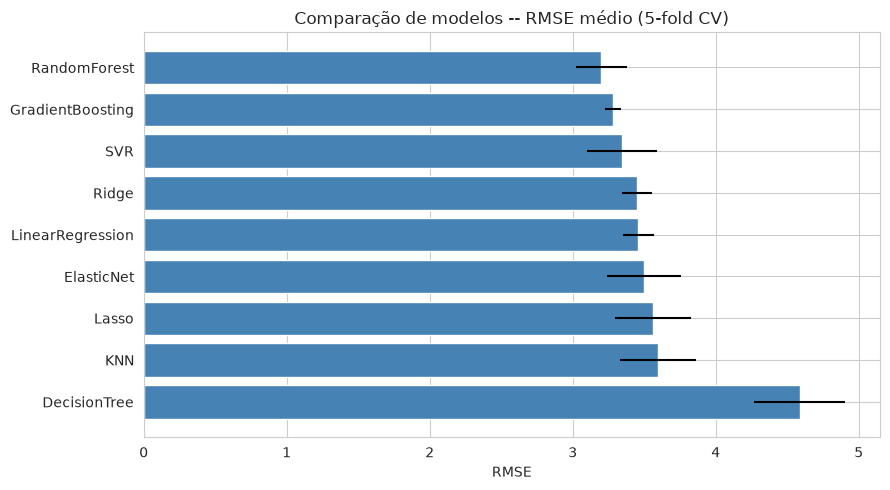

In [46]:
plt.figure(figsize=(9, 5))
plt.barh(results_reg_df["modelo"], results_reg_df["rmse_mean"],
         xerr=results_reg_df["rmse_std"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Comparação de modelos -- RMSE médio (5-fold CV)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()


**Seleção e ajuste fino:** o modelo com menor RMEE médio é refinado via `GridSearchCV`
(busca exaustiva em grade de hiperparâmetros, também com CV k=5), e reavaliado em um
holdout de 20% separado antes do ajuste, como checagem final independente da busca de
hiperparâmetros. O modelo final é reajustado (`fit`) em 100% do `train.csv` antes de
gerar as previsões em `test.csv`, maximizando os dados disponíveis para o modelo em
produção.

In [ ]:
# Ajuste fino leve do melhor modelo (exemplo com RandomForest)
best_model_name = results_reg_df.iloc[0]["modelo"]
print("Melhor modelo por CV:", best_model_name)

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
}
pipe_best = Pipeline([("prep", preprocessor_reg), ("model", RandomForestRegressor(random_state=RANDOM_STATE))])

grid = GridSearchCV(pipe_best, param_grid, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

val_pred = grid.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print("Melhores parâmetros:", grid.best_params_)
print(f"RMSE no conjunto de validação (holdout): {val_rmse:.3f}")
print(f"R2 no conjunto de validação: {r2_score(y_val, val_pred):.3f}")


Melhor modelo por CV: RandomForest


Melhores parâmetros: {'model__max_depth': 5, 'model__n_estimators': 400}
RMSE no conjunto de validação (holdout): 3.345
R2 no conjunto de validação: 0.245


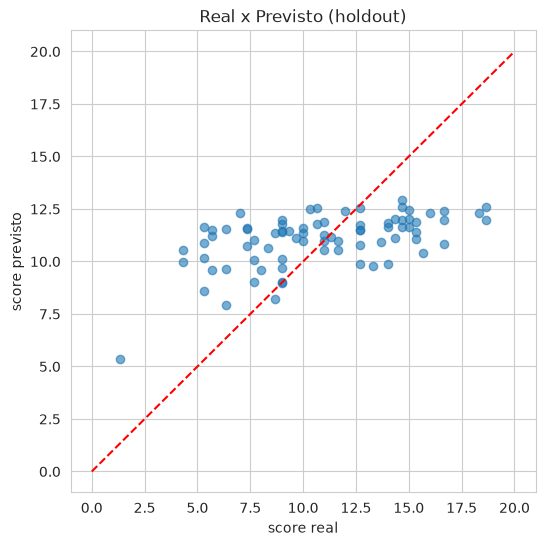

In [47]:
# Real x previsto no holdout
plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_pred, alpha=0.6)
lims = [0, 20]
plt.plot(lims, lims, "r--")
plt.xlabel("score real")
plt.ylabel("score previsto")
plt.title("Real x Previsto (holdout)")
plt.show()


In [56]:
# Reajusta o melhor pipeline em TODO o train.csv e gera as previsões para o test.csv
final_reg_pipe = grid.best_estimator_
final_reg_pipe.fit(X, y)

test_kaggle = pd.read_csv("regressao/test-kaggle.csv")
test_pred_reg = final_reg_pipe.predict(test_kaggle)
test_pred_reg = np.clip(test_pred_reg, 0, 20)  # score é limitado entre 0 e 20

submission_reg = pd.DataFrame({
    "id": range(len(test_pred_reg)), 
    "score": test_pred_reg
})
submission_reg.to_csv("regressao/submission.csv", index=False)
submission_reg.head()


,id,score
0,0,6.543666
1,1,11.692000
2,2,10.363918
3,3,12.071536
4,4,11.368710


In [48]:
# Checagem final antes de submeter
assert len(submission_reg) == len(test_reg), "número de linhas não bate com test.csv"
assert submission_reg.isnull().sum().sum() == 0, "há NaN na submissão"
assert submission_reg["score"].between(0, 20).all(), "há valores fora da faixa 0-20"
print("OK -- submission.csv da regressão pronto para o Kaggle.")


OK -- submission.csv da regressão pronto para o Kaggle.


---
# Parte 2: Classificação — Breast Cancer


## 2.1 Análise exploratória

In [29]:
df_clf = pd.read_csv("classiicacao/train2.csv")
test_clf = pd.read_csv("classiicacao/test2.csv")

print(df_clf.shape, test_clf.shape)
df_clf.head()


(569, 31) (20, 30)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [30]:
df_clf.info()
print("\nValores nulos:")
print(df_clf.isnull().sum()[df_clf.isnull().sum() > 0])


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


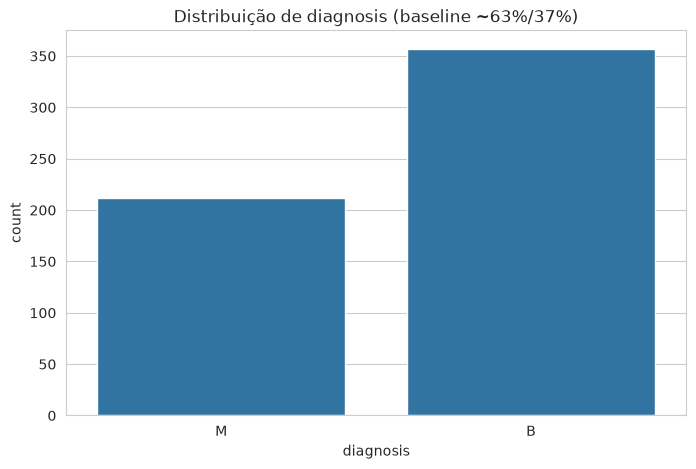

In [31]:
# Balanceamento das classes
print(df_clf["diagnosis"].value_counts())
print(df_clf["diagnosis"].value_counts(normalize=True))

sns.countplot(data=df_clf, x="diagnosis")
plt.title("Distribuição de diagnosis (baseline ~63%/37%)")
plt.show()


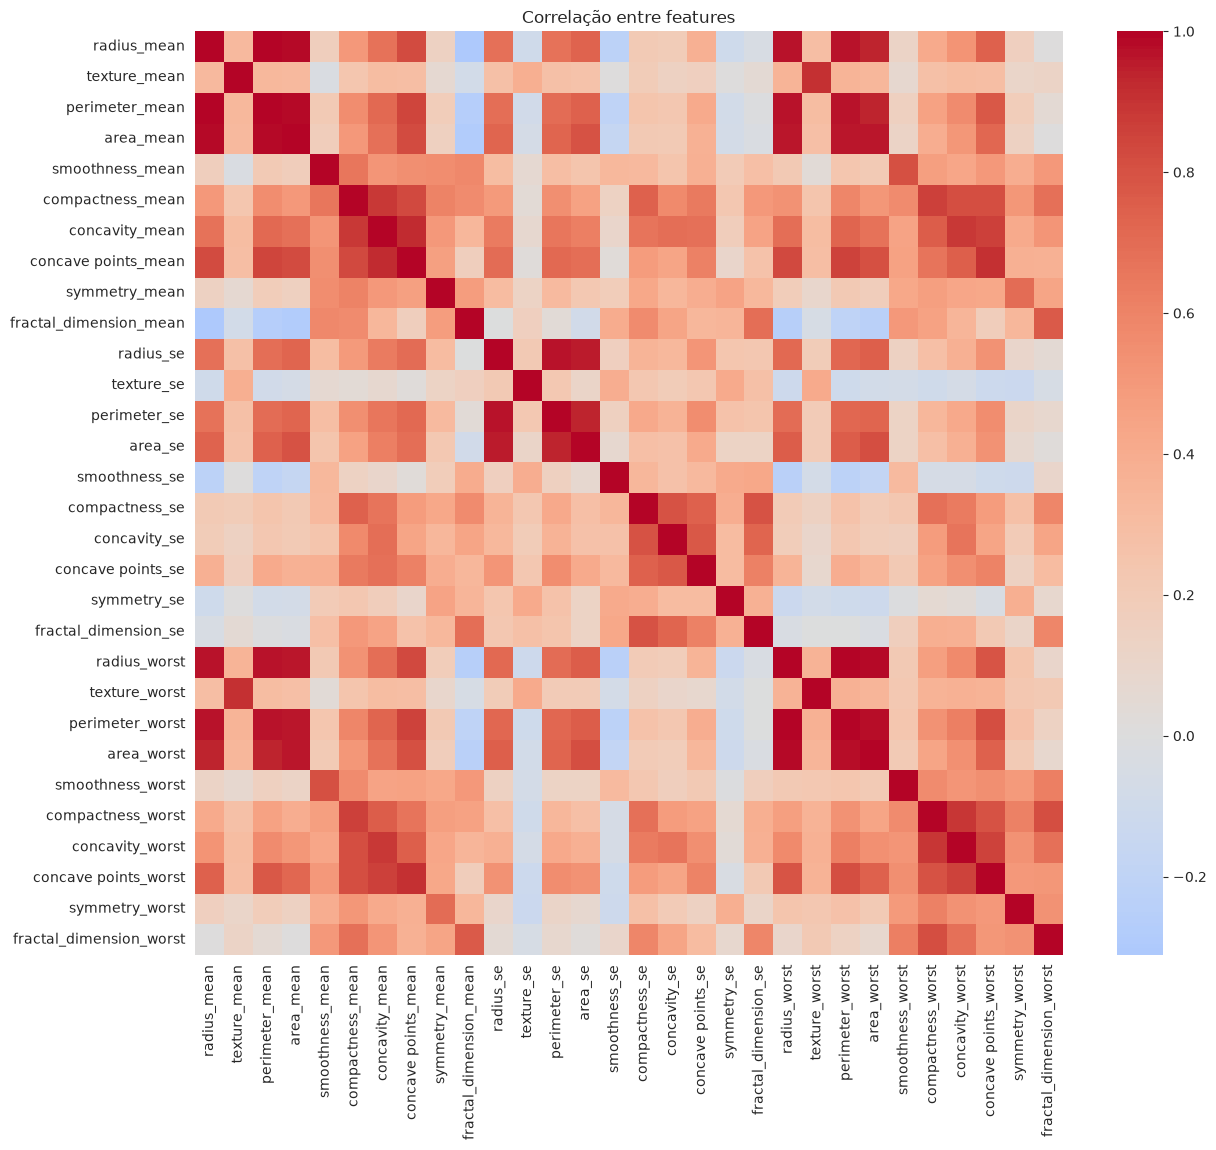

In [32]:
# Heatmap de correlação entre as features (identifica multicolinearidade forte,
# comum entre radius/perimeter/area, por exemplo)
feature_cols = [c for c in df_clf.columns if c != "diagnosis"]
plt.figure(figsize=(14, 12))
sns.heatmap(df_clf[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlação entre features")
plt.show()


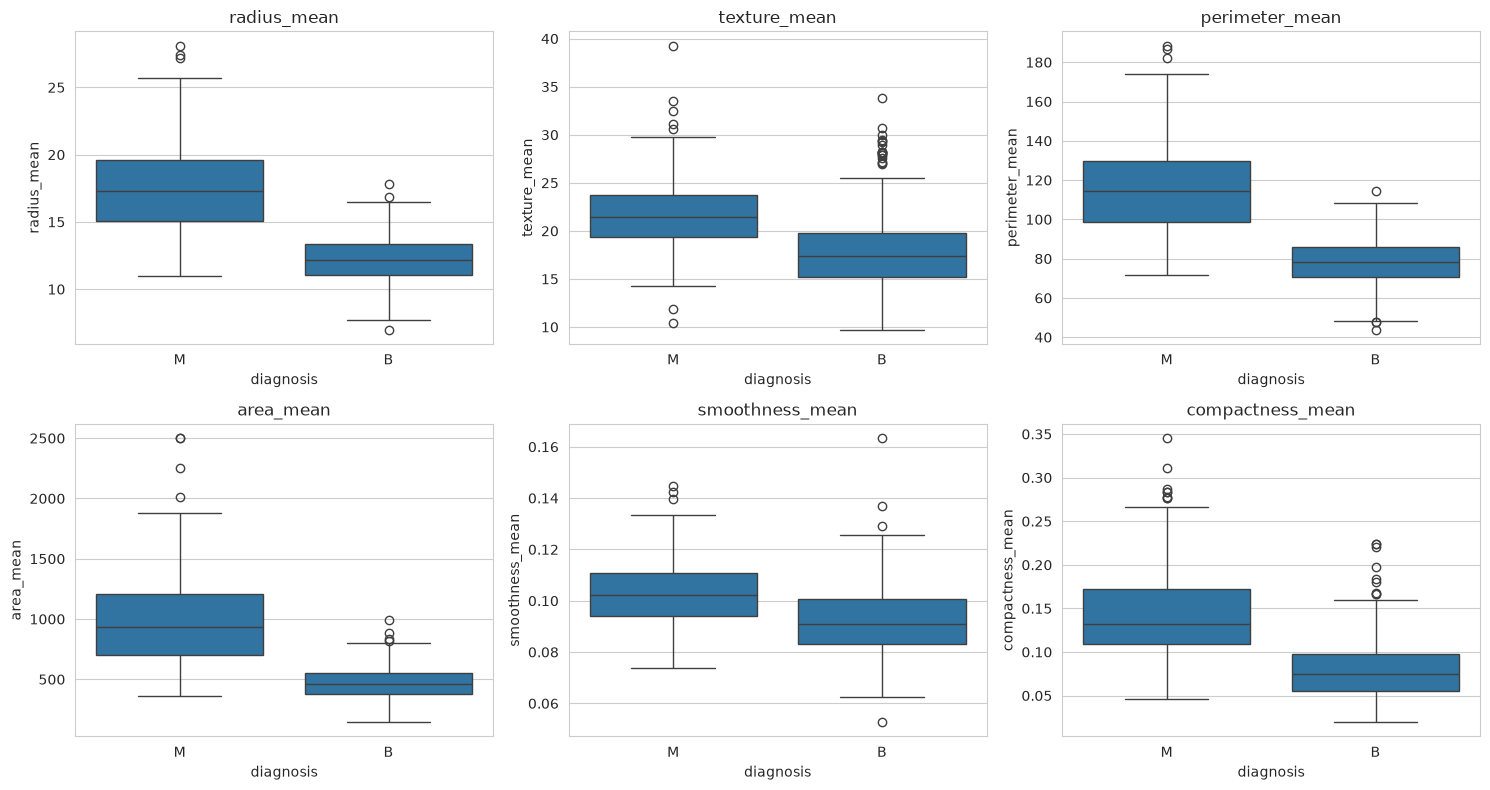

In [33]:
# Distribuição de algumas features-chave por diagnóstico
key_feats = [c for c in feature_cols if "_mean" in c][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), key_feats):
    sns.boxplot(data=df_clf, x="diagnosis", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


## 2.2 Pré-processamento

In [34]:
assert set(test_clf.columns) == set(df_clf.columns) - {"diagnosis"}, "colunas de test2.csv não batem com train2.csv"

# Confiram no sample_submission.csv se malignant=1/benign=0 ou o contrário antes de submeter
y_clf = df_clf["diagnosis"].map({"M": 1, "B": 0})
X_clf = df_clf.drop(columns=["diagnosis"])

preprocessor_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


## 2.3 Modelos de inferência

In [35]:
Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "GaussianNB": GaussianNB(),
    "SVM_linear": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
    "SVM_rbf": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}


## 2.4 Avaliação (acurácia + matriz de confusão)

In [36]:
skf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results_clf = []

for name, model in clf_models.items():
    pipe = Pipeline([("prep", preprocessor_clf), ("model", model)])
    acc_scores = cross_val_score(pipe, X_clf, y_clf, cv=skf, scoring="accuracy")
    results_clf.append({"modelo": name, "acc_mean": acc_scores.mean(), "acc_std": acc_scores.std()})
    print(f"{name:20s} acurácia = {acc_scores.mean():.4f} +/- {acc_scores.std():.4f}")

results_clf_df = pd.DataFrame(results_clf).sort_values("acc_mean", ascending=False)
results_clf_df


LogisticRegression   acurácia = 0.9771 +/- 0.0090
KNN                  acurácia = 0.9595 +/- 0.0191
GaussianNB           acurácia = 0.9367 +/- 0.0152


/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/leticia/projetos/analytica/git-training/venv/lib/python3.1

SVM_linear           acurácia = 0.9719 +/- 0.0129
SVM_rbf              acurácia = 0.9807 +/- 0.0066


/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


DecisionTree         acurácia = 0.9332 +/- 0.0162
RandomForest         acurácia = 0.9631 +/- 0.0086
GradientBoosting     acurácia = 0.9649 +/- 0.0096


,modelo,acc_mean,acc_std
4,SVM_rbf,0.980655,0.006615
0,LogisticRegression,0.977146,0.008964
3,SVM_linear,0.971868,0.012926
7,GradientBoosting,0.964850,0.009610
6,RandomForest,0.963096,0.008583
1,KNN,0.959525,0.019092
2,GaussianNB,0.936718,0.015151
5,DecisionTree,0.933225,0.016236


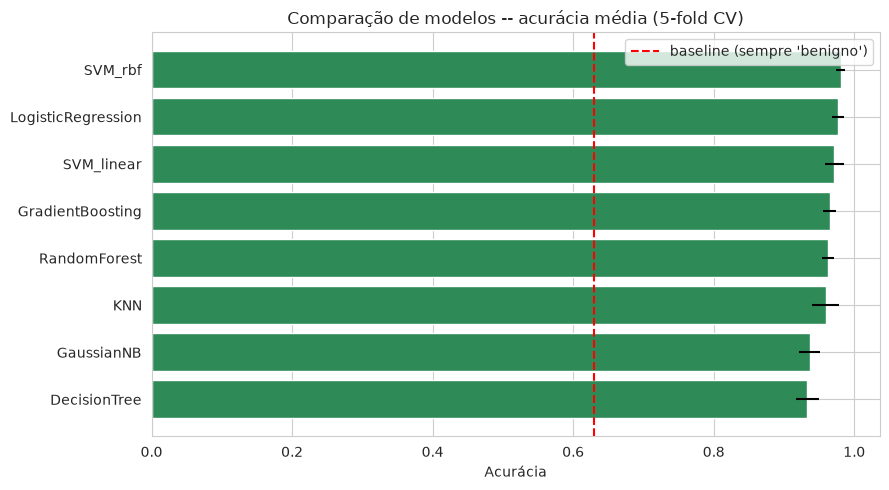

In [37]:
plt.figure(figsize=(9, 5))
plt.barh(results_clf_df["modelo"], results_clf_df["acc_mean"],
         xerr=results_clf_df["acc_std"], color="seagreen")
plt.gca().invert_yaxis()
plt.axvline(0.63, color="red", linestyle="--", label="baseline (sempre 'benigno')")
plt.legend()
plt.title("Comparação de modelos -- acurácia média (5-fold CV)")
plt.xlabel("Acurácia")
plt.tight_layout()
plt.show()


Melhor modelo por CV: SVM_rbf
Acurácia (holdout): 0.9737
              precision    recall  f1-score   support

 Benigno (0)       0.96      1.00      0.98        72
 Maligno (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


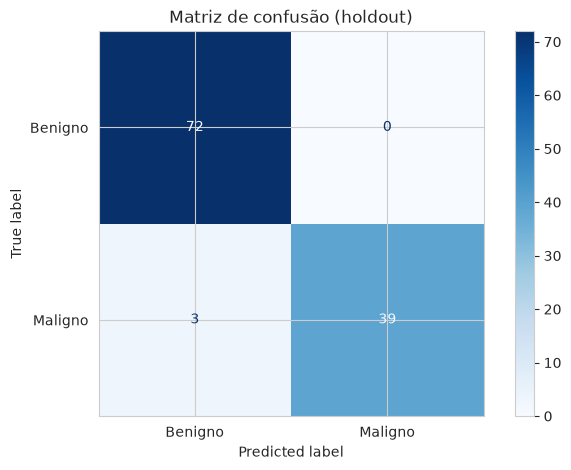

Verdadeiros negativos (benigno correto): 72
Falsos positivos (benigno previsto como maligno): 0
Falsos negativos (maligno previsto como benigno) -- o mais grave clinicamente: 3
Verdadeiros positivos (maligno correto): 39


In [38]:
# Treina o melhor modelo no split de treino e avalia no holdout com matriz de confusão
best_clf_name = results_clf_df.iloc[0]["modelo"]
print("Melhor modelo por CV:", best_clf_name)

best_clf_pipe = Pipeline([("prep", preprocessor_clf), ("model", clf_models[best_clf_name])])
best_clf_pipe.fit(Xc_train, yc_train)
yc_pred = best_clf_pipe.predict(Xc_val)

print(f"Acurácia (holdout): {accuracy_score(yc_val, yc_pred):.4f}")
print(classification_report(yc_val, yc_pred, target_names=["Benigno (0)", "Maligno (1)"]))

cm = confusion_matrix(yc_val, yc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno", "Maligno"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusão (holdout)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros negativos (benigno correto): {tn}")
print(f"Falsos positivos (benigno previsto como maligno): {fp}")
print(f"Falsos negativos (maligno previsto como benigno) -- o mais grave clinicamente: {fn}")
print(f"Verdadeiros positivos (maligno correto): {tp}")


**Anotem aqui**: nesse problema, um falso negativo (dizer que é benigno quando é maligno)
é clinicamente mais grave que um falso positivo. Comentem se o modelo escolhido comete esse
tipo de erro e se vale a pena otimizar por outra métrica (ex: recall da classe maligna).


In [ ]:
# Reajusta o melhor pipeline em TODO o train2.csv e gera as previsões para o test2.csv
final_clf_pipe = Pipeline([("prep", preprocessor_clf), ("model", clf_models[best_clf_name])])
final_clf_pipe.fit(X_clf, y_clf)

test_pred_clf = final_clf_pipe.predict(test_clf)

submission_clf = pd.DataFrame({
    "id": range(len(test_pred_clf)),   
    "diagnosis": test_pred_clf         
})
submission_clf.to_csv("classiicacao/submission.csv", index=False)
submission_clf.head()


/home/leticia/projetos/analytica/git-training/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,id,diagnosis
0,0,0
1,1,1
2,2,1
3,3,1
4,4,0


In [40]:
# Checagem final antes de submeter
assert len(submission_clf) == len(test_clf), "número de linhas não bate com test2.csv"
assert submission_clf.isnull().sum().sum() == 0, "há NaN na submissão"
assert set(submission_clf["diagnosis"].unique()).issubset({0, 1}), "valores fora de {0,1}"
print("OK -- submission.csv da classificação pronto para o Kaggle.")


OK -- submission.csv da classificação pronto para o Kaggle.
